# Clusters Analysis

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## Load and inspect data

In [2]:
DATA_DIR = "data/clusters"

time_series = pd.read_parquet(
    f"{DATA_DIR}/cluster_time_series.parquet"
)

snapshots = pd.read_parquet(
    f"{DATA_DIR}/cluster_snapshots.parquet"
)

size_counts = pd.read_parquet(
    f"{DATA_DIR}/cluster_size_counts.parquet"
)

raw = pd.read_parquet(
    f"{DATA_DIR}/cluster_raw.parquet"
)

In [3]:
print("N values:")
print(sorted(snapshots["N"].unique()))

print("\nrho values by N:")
for N, group in snapshots.groupby("N"):
    print(N, sorted(group["rho"].unique()))

print("\nNumber of seeds by N and rho:")
display(
    snapshots.groupby(["N", "rho"])["seed"]
    .nunique()
    .unstack()
)

N values:
[np.int64(10000)]

rho values by N:
10000 [np.float64(0.8), np.float64(0.81), np.float64(0.82), np.float64(0.83), np.float64(0.84), np.float64(0.85), np.float64(0.86), np.float64(0.87)]

Number of seeds by N and rho:


rho,0.80,0.81,0.82,0.83,0.84,0.85,0.86,0.87
N,,,,,,,,
10000,32,32,32,32,32,32,32,32


In [4]:
print("Phenotypes:")
print(time_series["phenotype"].unique())

print("\nTime series steps:")
print("min =", time_series["step"].min())
print("max =", time_series["step"].max())
print("number of unique steps =", time_series["step"].nunique())

print("\nSnapshots steps:")
print("min =", snapshots["step"].min())
print("max =", snapshots["step"].max())
print("number of unique steps =", snapshots["step"].nunique())

print("\nFirst time-series steps:")
print(sorted(time_series["step"].unique())[:20])

print("\nFirst snapshot steps:")
print(sorted(snapshots["step"].unique())[:20])

Phenotypes:
<ArrowStringArray>
['elongated', 'round']
Length: 2, dtype: str

Time series steps:
min = 0
max = 50000
number of unique steps = 501

Snapshots steps:
min = 0
max = 50000
number of unique steps = 51

First time-series steps:
[np.int64(0), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(1100), np.int64(1200), np.int64(1300), np.int64(1400), np.int64(1500), np.int64(1600), np.int64(1700), np.int64(1800), np.int64(1900)]

First snapshot steps:
[np.int64(0), np.int64(1000), np.int64(2000), np.int64(3000), np.int64(4000), np.int64(5000), np.int64(6000), np.int64(7000), np.int64(8000), np.int64(9000), np.int64(10000), np.int64(11000), np.int64(12000), np.int64(13000), np.int64(14000), np.int64(15000), np.int64(16000), np.int64(17000), np.int64(18000), np.int64(19000)]


In [5]:
display(
    time_series
    .groupby(["rho", "seed"])["step"]
    .agg(["min", "max", "nunique"])
    .groupby("rho")
    .agg(["min", "max"])
)

min        max        nunique     
     min max    min    max     min  max
rho                                    
0.80   0   0  50000  50000     501  501
0.81   0   0  50000  50000     501  501
0.82   0   0  50000  50000     501  501
0.83   0   0  50000  50000     501  501
0.84   0   0  50000  50000     501  501
0.85   0   0  50000  50000     501  501
0.86   0   0  50000  50000     501  501
0.87   0   0  50000  50000     501  501

## Time Series

In [6]:
# Average over seeds at each time
# We group by density, step, and phenotype,
# and then compute the mean and standard deviation of S1_over_N across seeds.
s1_time = (
    time_series
    .groupby(["rho", "step", "phenotype"])["S1_over_N"]
    .agg(["mean", "std"])
    .reset_index()
)

# Show the first few rows of the averaged time series data
s1_time.head()

,rho,step,phenotype,mean,std
0,0.8,0,elongated,0.000000,0.000000
1,0.8,0,round,0.007010,0.000965
2,0.8,100,elongated,0.000240,0.000070
3,0.8,100,round,0.008042,0.001769
4,0.8,200,elongated,0.000347,0.000122


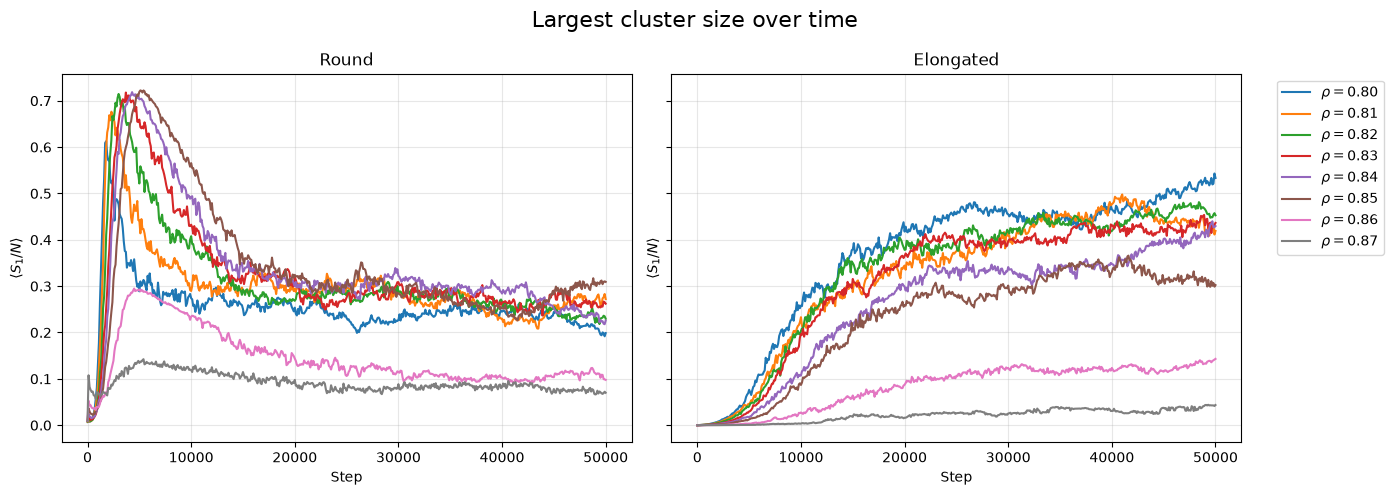

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, phenotype in zip(axs, ["round", "elongated"]):

    df_pheno = s1_time[
        s1_time["phenotype"] == phenotype
    ]

    for rho, df_rho in df_pheno.groupby("rho"):

        ax.plot(
            df_rho["step"],
            df_rho["mean"],
            label=fr"$\rho={rho:.2f}$"
        )

    ax.set_title(phenotype.capitalize())
    ax.set_xlabel("Step")
    ax.set_ylabel(r"$\langle S_1/N \rangle$")
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.grid(alpha=0.3)

axs[1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

graph_title = "Largest cluster size over time"
fig.suptitle(graph_title, fontsize=16)
rout_title = graph_title.lower().replace(" ", "_")
folder_name = "figures/clusters"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
plt.tight_layout()
plt.savefig(f"{folder_name}/{rout_title}.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
cluster_structure_time = (
    time_series
    .groupby(["rho", "step", "phenotype"])[
        ["fraction_phenotype", "S1_over_Nphenotype"]
    ]
    .mean()
    .reset_index()
)

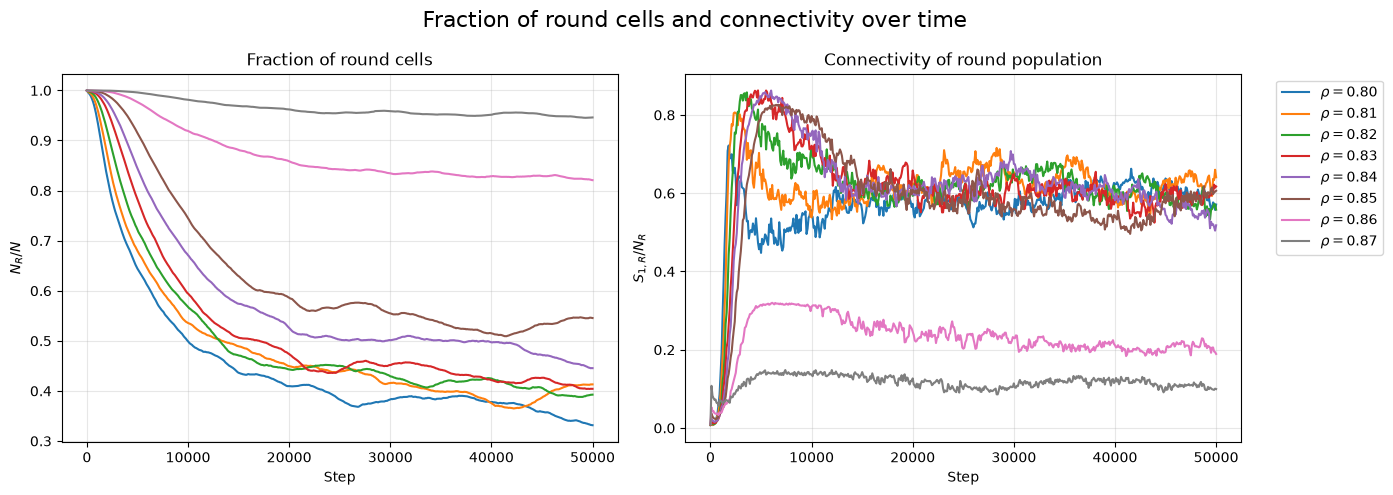

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

df_round = cluster_structure_time[
    cluster_structure_time["phenotype"] == "round"
]

for rho, df_rho in df_round.groupby("rho"):

    axs[0].plot(
        df_rho["step"],
        df_rho["fraction_phenotype"],
        label=fr"$\rho={rho:.2f}$"
    )

    axs[1].plot(
        df_rho["step"],
        df_rho["S1_over_Nphenotype"],
        label=fr"$\rho={rho:.2f}$"
    )

axs[0].set_title("Fraction of round cells")
axs[0].set_xlabel("Step")
axs[0].set_ylabel(r"$N_R/N$")

axs[1].set_title("Connectivity of round population")
axs[1].set_xlabel("Step")
axs[1].set_ylabel(r"$S_{1,R}/N_R$")

for ax in axs:
    ax.grid(alpha=0.3)

axs[1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

graph_title = "Fraction of round cells and connectivity over time"
fig.suptitle(graph_title, fontsize=16)
rout_title = graph_title.lower().replace(" ", "_")
folder_name = "figures/clusters"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
plt.tight_layout()
plt.savefig(f"{folder_name}/{rout_title}.png", dpi=300, bbox_inches="tight")
plt.show()

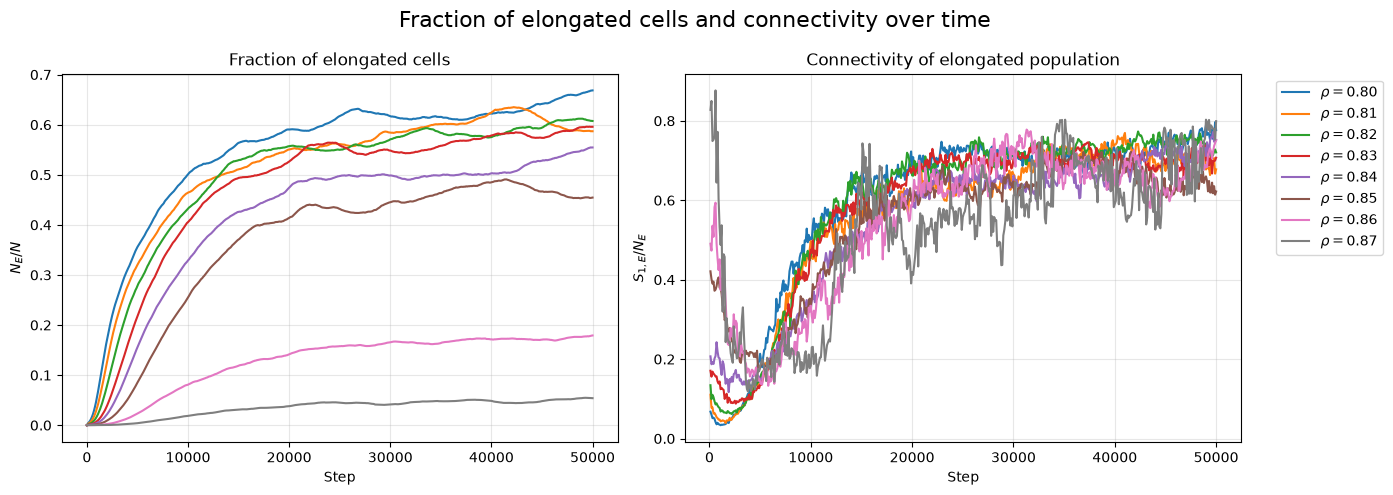

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

df_round = cluster_structure_time[
    cluster_structure_time["phenotype"] == "elongated"
]

for rho, df_rho in df_round.groupby("rho"):

    axs[0].plot(
        df_rho["step"],
        df_rho["fraction_phenotype"],
        label=fr"$\rho={rho:.2f}$"
    )

    axs[1].plot(
        df_rho["step"],
        df_rho["S1_over_Nphenotype"],
        label=fr"$\rho={rho:.2f}$"
    )

axs[0].set_title("Fraction of elongated cells")
axs[0].set_xlabel("Step")
axs[0].set_ylabel(r"$N_E/N$")

axs[1].set_title("Connectivity of elongated population")
axs[1].set_xlabel("Step")
axs[1].set_ylabel(r"$S_{1,E}/N_E$")

for ax in axs:
    ax.grid(alpha=0.3)

axs[1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

graph_title = "Fraction of elongated cells and connectivity over time"
fig.suptitle(graph_title, fontsize=16)
rout_title = graph_title.lower().replace(" ", "_")
folder_name = "figures/clusters"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
plt.tight_layout()
plt.savefig(f"{folder_name}/{rout_title}.png", dpi=300, bbox_inches="tight")
plt.show()